<h1 style="text-align: center;">SMT Challenge 2025 Jump Expected Model</h1>
<h3 style="text-align: center;"><i>Team 15</i> - this notebook is used to develop the model that will model the expected reaction, burst, and route components of Jump</h3>

### Necessary Libraries

In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from pygam import LinearGAM, s, f
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error

np.random.seed(42)

pd.set_option('display.max_columns', None)

### Loading in the Data

In [41]:
jump_df = pd.read_csv('catch_probabilities.csv').iloc[:, 1:].copy()
jump_df.loc[:, 'p_catch'] = jump_df['p_catch'].apply(lambda x: x*100)
jump_df.loc[:, 'player_attempt'] = jump_df['player_attempt'].astype(int)
## we're going to have separate models for each metric
## makes sure that metric doesn't have null values
jump_reaction_df = jump_df[~jump_df['reaction'].isna()].reset_index(drop=True).copy()
jump_burst_df = jump_df[~jump_df['burst'].isna()].reset_index(drop=True).copy()
jump_route_df = jump_df[~jump_df['route'].isna()].reset_index(drop=True).copy()

### Helper Functions

In [221]:
def partial_dependence_plots(model, features: list) -> None:
    """
    Visualizes the partial dependencies of each feature
    The code is mostly taken from pyGAM's documentation: https://pygam.readthedocs.io/en/latest/notebooks/tour_of_pygam.html
    
    Arguments: model: fitted GAM model, features: list of features (must match order of columns in training data)
    """
    fig, axs = plt.subplots(1, len(features), figsize=(5 * len(features), 4))

    for i, ax in enumerate(axs):
        XX = model.generate_X_grid(term=i)
        pdep, confi = model.partial_dependence(term=i, width=.95)
        ax.plot(XX[:, i], pdep)
        ax.plot(XX[:, i], confi, c='r', ls='--')
        ax.set_title(features[i])
        ax.set_xlabel(features[i])
        ax.set_ylabel("Log-Odds")
    plt.tight_layout()
    plt.show()

### Reaction Model

#### EDA

##### Left Fielder

In [231]:
lf_jump_reaction = jump_reaction_df[jump_reaction_df['player_attempt'] == 7]

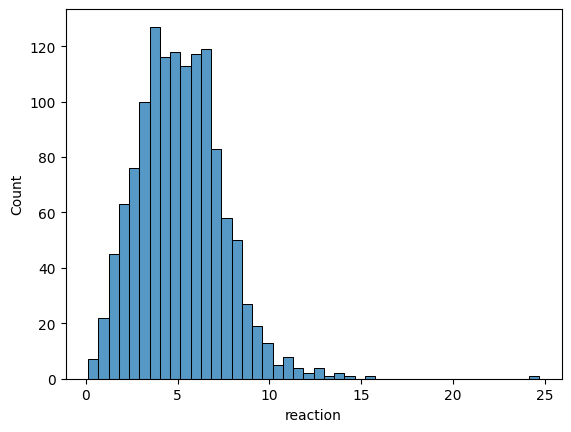

In [235]:
plt.figure()
sns.histplot(data=lf_jump_reaction, x='reaction')
plt.show()

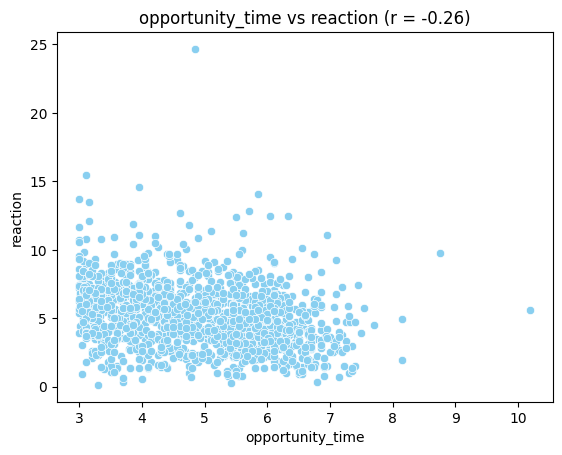

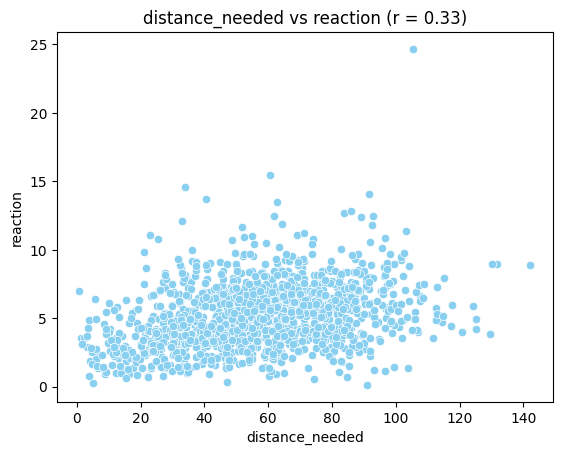

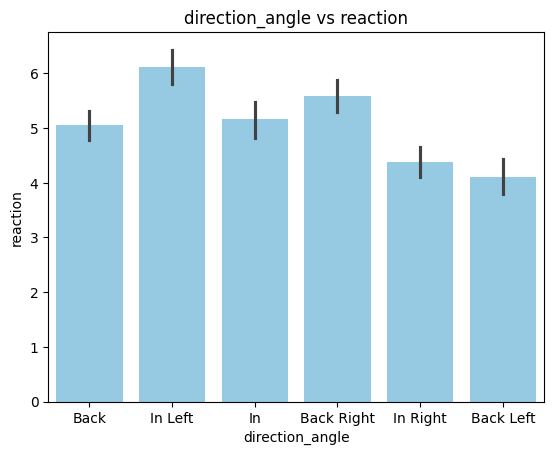

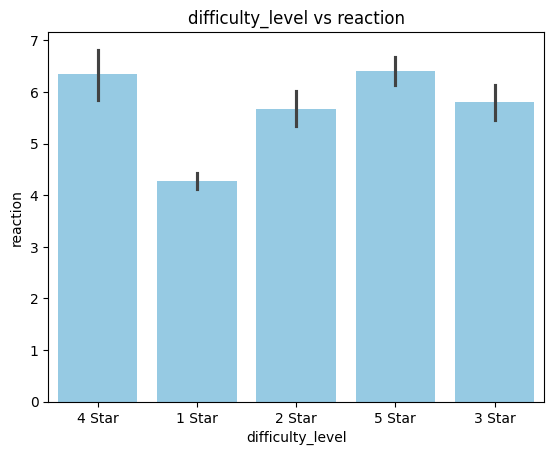

In [232]:
plt.figure()
sns.scatterplot(data=lf_jump_reaction, x='opportunity_time', y='reaction', color='#89CFF0')
r_ot, p_ot = stats.pearsonr(lf_jump_reaction['opportunity_time'], lf_jump_reaction['reaction'])
plt.title(f'opportunity_time vs reaction (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=lf_jump_reaction, x='distance_needed', y='reaction', color='#89CFF0')
r_dn, p_dn = stats.pearsonr(lf_jump_reaction['distance_needed'], lf_jump_reaction['reaction'])
plt.title(f'distance_needed vs reaction (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.barplot(data=lf_jump_reaction, x='direction_angle', y='reaction', color='#89CFF0')
plt.title('direction_angle vs reaction')
plt.show()

plt.figure()
sns.barplot(data=lf_jump_reaction, x='difficulty_level', y='reaction', color='#89CFF0')
plt.title('difficulty_level vs reaction')
plt.show()

In [227]:
## prepares the features of jump_reaction_df to fit the model
X_7_reaction = lf_jump_reaction[['opportunity_time', 'distance_needed', 'direction_angle', 'difficulty_level']].copy()
X_7_reaction.loc[:, 'direction_cat_code'] = X_7_reaction['direction_angle'].astype('category').cat.codes
X_7_reaction.loc[:, 'difficulty_cat_code'] = X_7_reaction['difficulty_level'].astype('category').cat.codes
X_7_reaction_scaled = scaler.fit_transform(X_7_reaction[['opportunity_time', 'distance_needed']].values)
X_7_reaction_params = np.hstack([X_7_reaction_scaled, X_7_reaction[['direction_cat_code', 'difficulty_cat_code']].values])
y_7_reaction = lf_jump_reaction['reaction'].values

In [228]:
## reaction model for left fielder
X_7_train, X_7_temp, y_7_train, y_7_temp = train_test_split(X_7_reaction_params, y_7_reaction, test_size=0.4, random_state=42)
X_7_val, X_7_test, y_7_val, y_7_test = train_test_split(X_7_temp, y_7_temp, test_size=0.5, random_state=42)

grid_reaction_7_gam = LinearGAM(s(0) + s(1) + f(2) + f(3)).gridsearch(X_7_train, y_7_train, lam=np.logspace(-3, 3, 10))
print(grid_reaction_7_gam.lam)
reaction_7_gam = LinearGAM(s(0, lam=10) + s(1, lam=10) + f(2, lam=10) + f(3, lam=10)).fit(X_7_train, y_7_train)
reaction_7_gam.summary()

  0% (0 of 10) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 10% (1 of 10) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:04
 20% (2 of 10) |#####                    | Elapsed Time: 0:00:00 ETA:   0:00:02
 50% (5 of 10) |############             | Elapsed Time: 0:00:00 ETA:   0:00:00
 80% (8 of 10) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (10 of 10) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


[[46.41588833612773], [46.41588833612773], [46.41588833612773], [46.41588833612773]]
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     22.3791
Link Function:                     IdentityLink Log Likelihood:                                 -1818.4409
Number of Samples:                          781 AIC:                                               3683.64
                                                AICc:                                            3685.1466
                                                GCV:                                                3.7671
                                                Scale:                                              3.5733
                                                Pseudo R-Sq

/var/folders/6l/fh4ck8px62x4x7vp3j9kjr6h0000gn/T/ipykernel_11308/702861240.py:8: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  reaction_7_gam.summary()


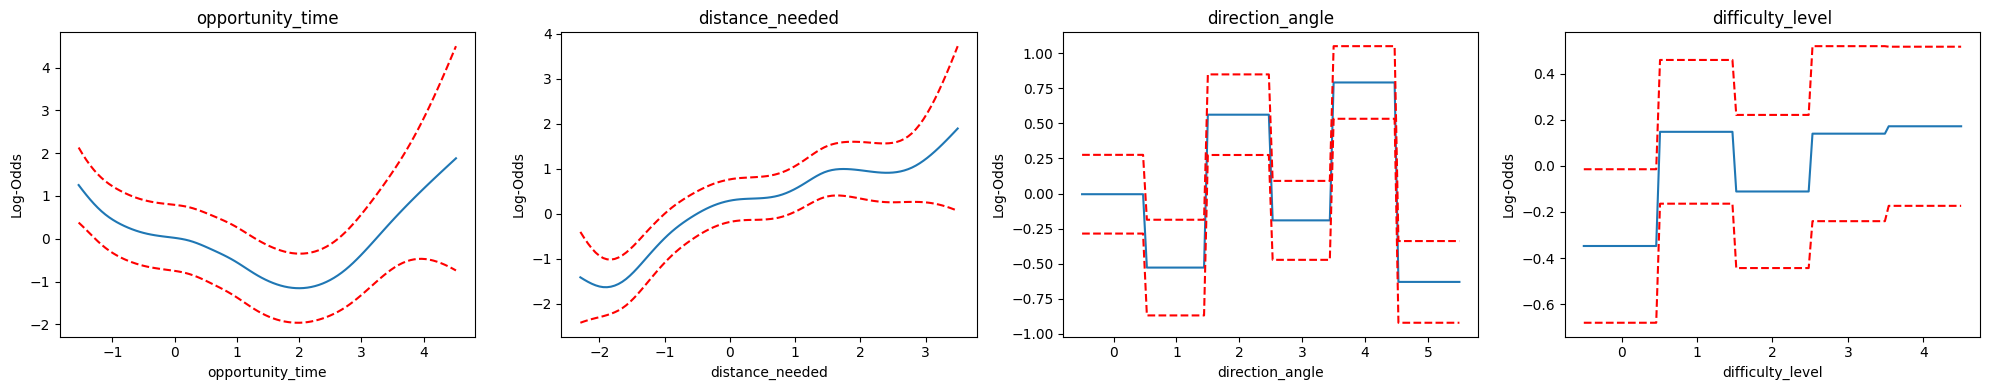

In [229]:
partial_dependence_plots(reaction_7_gam, ['opportunity_time', 'distance_needed', 'direction_angle', 'difficulty_level'])

In [230]:
y_reaction_7_pred = gamma_results.predict(X_7_test_const)
reaction_7_rmse = root_mean_squared_error(y_7_test, y_reaction_7_pred)
reaction_7_mape = mean_absolute_percentage_error(y_7_test, y_reaction_7_pred)
reaction_7_rmse, reaction_7_mape

(5.002146680958585, 0.7579765587229982)

##### Center Fielder

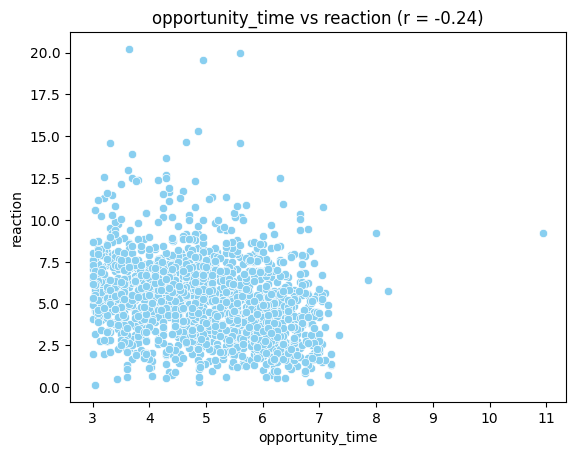

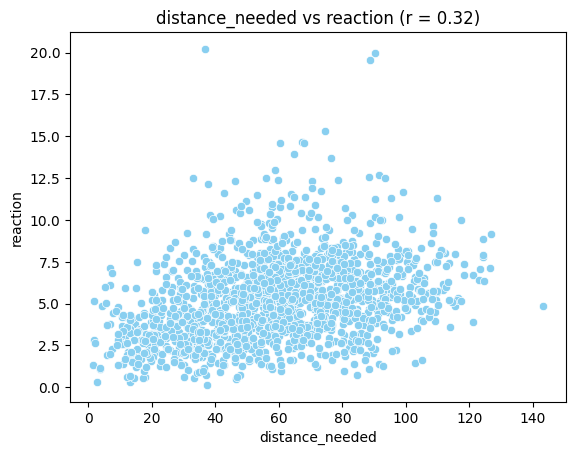

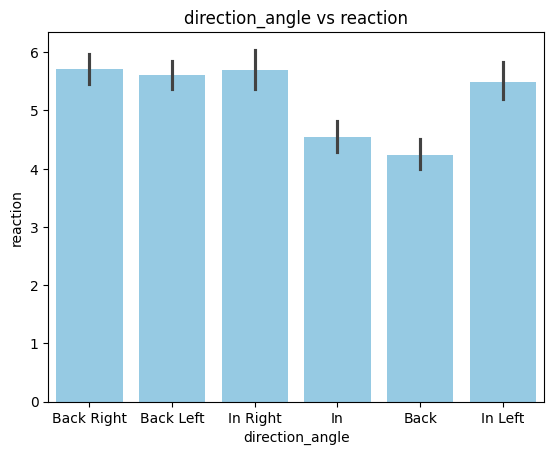

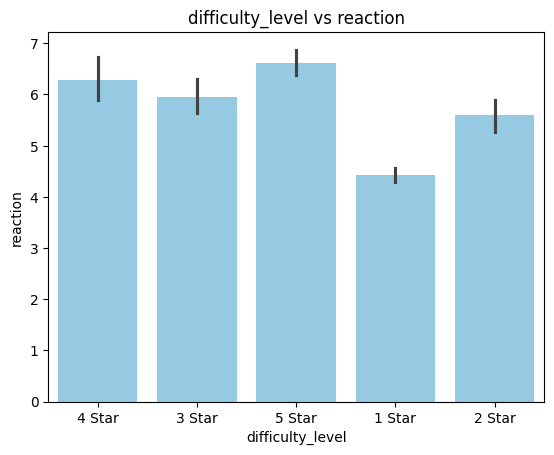

In [191]:
cf_jump_reaction = jump_reaction_df[jump_reaction_df['player_attempt'] == 8]

plt.figure()
sns.scatterplot(data=cf_jump_reaction, x='opportunity_time', y='reaction', color='#89CFF0')
r_ot, p_ot = stats.pearsonr(cf_jump_reaction['opportunity_time'], cf_jump_reaction['reaction'])
plt.title(f'opportunity_time vs reaction (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=cf_jump_reaction, x='distance_needed', y='reaction', color='#89CFF0')
r_dn, p_dn = stats.pearsonr(cf_jump_reaction['distance_needed'], cf_jump_reaction['reaction'])
plt.title(f'distance_needed vs reaction (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.barplot(data=cf_jump_reaction, x='direction_angle', y='reaction', color='#89CFF0')
plt.title('direction_angle vs reaction')
plt.show()

plt.figure()
sns.barplot(data=cf_jump_reaction, x='difficulty_level', y='reaction', color='#89CFF0')
plt.title('difficulty_level vs reaction')
plt.show()

##### Right Fielder

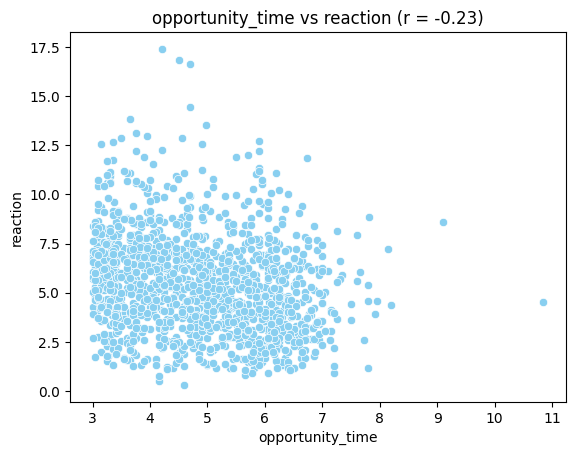

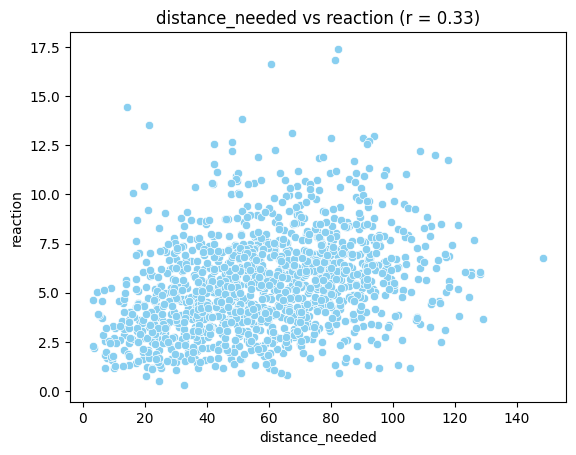

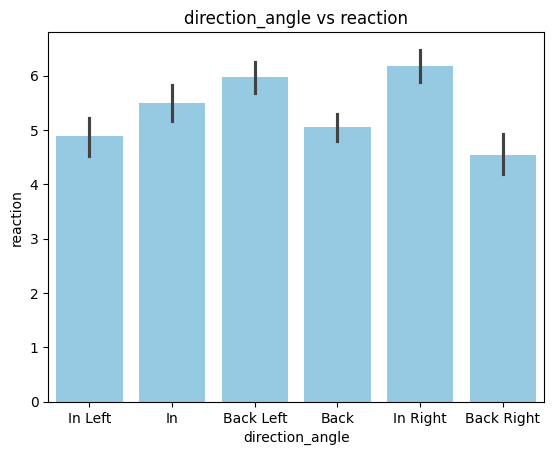

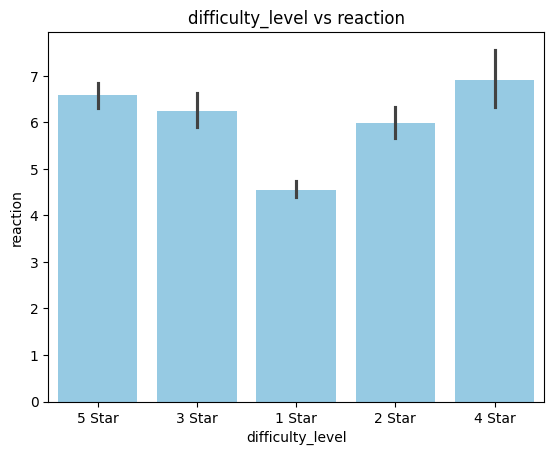

In [192]:
rf_jump_reaction = jump_reaction_df[jump_reaction_df['player_attempt'] == 9]

plt.figure()
sns.scatterplot(data=rf_jump_reaction, x='opportunity_time', y='reaction', color='#89CFF0')
r_ot, p_ot = stats.pearsonr(rf_jump_reaction['opportunity_time'], rf_jump_reaction['reaction'])
plt.title(f'opportunity_time vs reaction (r = {round(r_ot, 2)})')
plt.show()

plt.figure()
sns.scatterplot(data=rf_jump_reaction, x='distance_needed', y='reaction', color='#89CFF0')
r_dn, p_dn = stats.pearsonr(rf_jump_reaction['distance_needed'], rf_jump_reaction['reaction'])
plt.title(f'distance_needed vs reaction (r = {round(r_dn, 2)})')
plt.show()

plt.figure()
sns.barplot(data=rf_jump_reaction, x='direction_angle', y='reaction', color='#89CFF0')
plt.title('direction_angle vs reaction')
plt.show()

plt.figure()
sns.barplot(data=rf_jump_reaction, x='difficulty_level', y='reaction', color='#89CFF0')
plt.title('difficulty_level vs reaction')
plt.show()

#### Modeling

In [ ]:
## prepares the features of jump_reaction_df to fit the model
X_reaction = jump_reaction_df[['opportunity_time', 'distance_needed', 'direction_angle', 'player_attempt', 'difficulty_level']].copy()
X_reaction.loc[:, 'direction_cat_code'] = X_reaction['direction_angle'].astype('category').cat.codes
X_reaction.loc[:, 'difficulty_cat_code'] = X_reaction['difficulty_level'].astype('category').cat.codes
X_reaction.loc[:, 'player_cat_code'] = X_reaction['player_attempt'].astype('category').cat.codes
X_reaction_scaled = scaler.fit_transform(X_reaction[['opportunity_time', 'distance_needed']].values)
X_reaction_params = np.hstack([X_reaction_scaled, X_reaction[['direction_cat_code', 'difficulty_cat_code', 'player_cat_code']].values])
X_reaction_params = np.hstack([X_reaction_scaled, X_reaction[['direction_cat_code']].values])
y_reaction = jump_reaction_df['reaction'].values

In [185]:
## reaction model: random forest regressor
X_train, X_temp, y_train, y_temp = train_test_split(X_reaction_params, y_reaction, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

X_train = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train)
results = model.fit()
print(results.summary())
# reaction_lm = LinearRegression().fit(X_train, y_train)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.197
Method:                 Least Squares   F-statistic:                     208.0
Date:                Tue, 22 Jul 2025   Prob (F-statistic):          1.33e-120
Time:                        22:49:55   Log-Likelihood:                -5539.1
No. Observations:                2538   AIC:                         1.109e+04
Df Residuals:                    2534   BIC:                         1.111e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1576      0.076     67.710      0.0

In [182]:
print(f"Coefficients: {reaction_lm.coef_}")
print(f"Intercept: {reaction_lm.intercept_}")

Coefficients: [-0.66522906  0.82435782  0.05003606  0.05828227  0.15208538]
Intercept: 4.926153151801281


In [180]:
## model results
## linear model
y_test_reaction_lm_pred = reaction_lm.predict(X_test)
y_val_reaction_lm_pred = reaction_lm.predict(X_val)
test_reaction_lm_rmse = root_mean_squared_error(y_test, y_test_reaction_lm_pred)
val_reaction_lm_rmse = root_mean_squared_error(y_val, y_val_reaction_lm_pred)
test_reaction_lm_mape = mean_absolute_percentage_error(y_test, y_test_reaction_lm_pred)
val_reaction_lm_mape = mean_absolute_percentage_error(y_val, y_val_reaction_lm_pred)
print(f'linear model: test rmse: {round(test_reaction_lm_rmse, 3)}, val rmse: {round(val_reaction_lm_rmse, 3)}')
print(f'linear model: test mape: {round(test_reaction_lm_mape, 3)}, val mape: {round(val_reaction_lm_mape, 3)}')

linear model: test rmse: 2.23, val rmse: 2.101
linear model: test mape: 0.482, val mape: 0.469


In [177]:
jump_reaction_df['reaction'].std()

2.3983265695141323

### Burst Model

### Route Model